# Jump Height — Two-Mass Model with Motor Torque-Speed Curve

Why wheel mass matters more than body mass, and how the motor operating regime changes that story.

## 1 — Model

```
        ┌─────────┐
        │    M    │  ← body mass
        └────┬────┘
             │  actuator: F_max, v_max
        ┌────┴────┐
        │    m    │  ← leg / wheel mass  (ground contact)
        └─────────┘
        ══════════════  ground
```

**Assumptions:** one body $M$, one leg $m$, linear actuator with stroke $d$.  
Leg stays grounded throughout extension. At liftoff the leg is stationary — the body picks it up inelastically.

## 2 — Motor Torque-Speed Curve

A brushless motor has a linear torque-speed relationship:

$$F(v) = F_\text{max}\left(1 - \frac{v}{v_\text{max}}\right)$$

where $v$ is the actuator extension velocity, $F_\text{max}$ is the stall force, and $v_\text{max}$ is the no-load speed.  
Peak mechanical power is at $v = v_\text{max}/2$:

$$P_\text{peak} = \frac{F_\text{max}\, v_\text{max}}{4}$$

### Two operating regimes

**Torque-limited (heavy $M$, slow extension):**  
Body accelerates slowly → actuator velocity stays low → motor operates near stall → delivers close to $F_\text{max}$ over the full stroke $d$.  
Work done: $W \approx F_\text{max} \cdot d$ (constant, independent of $M$).

**Speed-limited (light $M$, fast extension):**  
Body accelerates quickly → actuator hits $v_\text{max}$ before the stroke ends → force drops to zero → rest of stroke wasted.  
Body velocity caps at: $V = v_\text{max}$ regardless of $M$.

### Crossover mass — optimal body mass

$$\boxed{M^* = \frac{2\,F_\text{max}\,d}{v_\text{max}^2}}$$

- $M < M^*$: **speed-limited** — body reaches $v_\text{max}$ before full extension; remaining stroke delivers zero work. Jump height *increases* with $M$ in this regime.
- $M > M^*$: **torque-limited** — full stroke is used; jump height *decreases* with $M$ in this regime.

**$M^*$ is the optimal body mass for maximum jump height.** It is the exact point where the actuator delivers its maximum possible work ($W = F_\text{max} \cdot d$, full stroke, no speed capping) with the lightest body that can absorb it without going speed-limited. Above $M^*$ you over-load the motor and carry dead weight; below $M^*$ you under-load it and waste stroke. The h vs $M$ curve peaks here.

## 3 — Jump Height per Regime

### Torque-limited ($M > M^*$)

$$V = \sqrt{\frac{2W}{M}}, \qquad W = F_\text{max}\,d$$

$$\boxed{h_\text{torque} = \frac{W\,M}{g\,(M+m)^2}}$$

$\partial h/\partial M < 0$ for $M > m$ — heavier body hurts.

### Speed-limited ($M < M^*$)

$$V = v_\text{max} \quad\text{(capped by motor speed)}$$

$$\boxed{h_\text{speed} = \frac{M^2\,v_\text{max}^2}{2g\,(M+m)^2}}$$

$\partial h/\partial M > 0$ — **heavier body jumps higher** in this regime!

### Sensitivity ratio per regime

| Regime | $|\partial h/\partial m|\,/\,|\partial h/\partial M|$ |
|---|---|
| Torque-limited | $2M\,/\,(M-m)$ ≈ **4.1×** for our robot |
| Speed-limited | $M\,/\,m$ ≈ **1.9×** for our robot |

Leg mass always hurts more per kg than body mass, but the gap is larger in the torque-limited regime.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML
import ipywidgets as widgets

g = 9.81

# ── Robot baseline (params.py) ───────────────────────────────────────────────
M0    = 0.985   # kg  body mass
m0    = 0.510   # kg  wheel mass
# AK45-10 @ 24V: peak torque 7 Nm, no-load speed 18.85 rad/s output-side
# Mapped to linear via approximate linkage jacobian ~0.10 m/rad at mid-stroke
J     = 0.10    # m/rad  effective jacobian (torque → force, ω → velocity)
F_max = 7.0 / J        # N   stall force
v_max = 18.85 * J      # m/s no-load velocity
d     = 0.062          # m   stroke (from params: 61.93 deg * J rough)
W0    = F_max * d      # J   max work (torque-limited)

print(f"F_max = {F_max:.1f} N")
print(f"v_max = {v_max:.3f} m/s")
print(f"W0    = {W0:.2f} J")
print(f"M*    = {2*W0/v_max**2:.2f} kg  (crossover mass)")

F_max = 70.0 N
v_max = 1.885 m/s
W0    = 4.34 J
M*    = 2.44 kg  (crossover mass)


In [2]:
def crossover_mass(F_max, v_max, d):
    W = F_max * d
    return 2 * W / v_max**2

def jump_height(M, m, F_max, v_max, d, g=9.81):
    """Jump height accounting for torque-speed regime."""
    W  = F_max * d
    Mc = crossover_mass(F_max, v_max, d)
    if np.ndim(M) == 0:  # scalar
        if M <= Mc:
            V = v_max
        else:
            V = np.sqrt(2 * W / M)
        V_sys = M * V / (M + m)
        return V_sys**2 / (2 * g)
    else:  # array
        V = np.where(M <= Mc, v_max, np.sqrt(2 * W / np.maximum(M, 1e-9)))
        V_sys = M * V / (M + m)
        return V_sys**2 / (2 * g)

def body_liftoff_velocity(M, F_max, v_max, d):
    W  = F_max * d
    Mc = crossover_mass(F_max, v_max, d)
    return np.where(M <= Mc, v_max, np.sqrt(2 * W / np.maximum(M, 1e-9)))

## 3b — 2× AK45-10 Analysis: Optimal Body Mass and Stroke

With both legs jumping simultaneously each AK45-10 contributes force independently, so the total stall force doubles while $v_\text{max}$ is unchanged (each motor still spins at the same no-load speed):

$$F_\text{max,2x} = 2\,F_\text{max}, \qquad v_\text{max,2x} = v_\text{max}, \qquad d_\text{2x} = d$$

$$M^*_\text{2x} = \frac{2 \cdot 2F_\text{max} \cdot d}{v_\text{max}^2} = 2\,M^*_\text{1x}$$

The optimal body mass doubles when you add the second motor. The code cell below computes exact numbers and comments on how much of the current stroke is actually used.

═══════════════════════════════════════════════════
  2× AK45-10 JUMP ANALYSIS
═══════════════════════════════════════════════════
  F_max per leg       = 70.0 N
  F_max both legs     = 140.0 N
  v_max (unchanged)   = 1.885 m/s
  Stroke d            = 62.0 mm

  M* (1 motor)        = 2.44 kg
  M* (2 motors)       = 4.89 kg   ← optimal body mass

── Robot at M = 0.985 kg (way below M*_2x) ──
  Effective stroke used  = 12.5 mm  of 62.0 mm  (20%)
  Stroke wasted          = 49.5 mm  (80%)
  Time to reach v_max    ≈ 13.3 ms  (then motor freewheels)

  h with 1× motor        = 78.6 mm
  h with 2× motors       = 78.6 mm   (no improvement — speed-limited in both cases)

── What stroke would match M=0.985 kg to 2× motors? ──
  d_optimal              = 12.5 mm  (vs current 62.0 mm)
  → current stroke is 5.0× longer than needed for this body mass

── If body were at optimal M*_2x = 4.89 kg ──
  h at M*_2x             = 148.5 mm


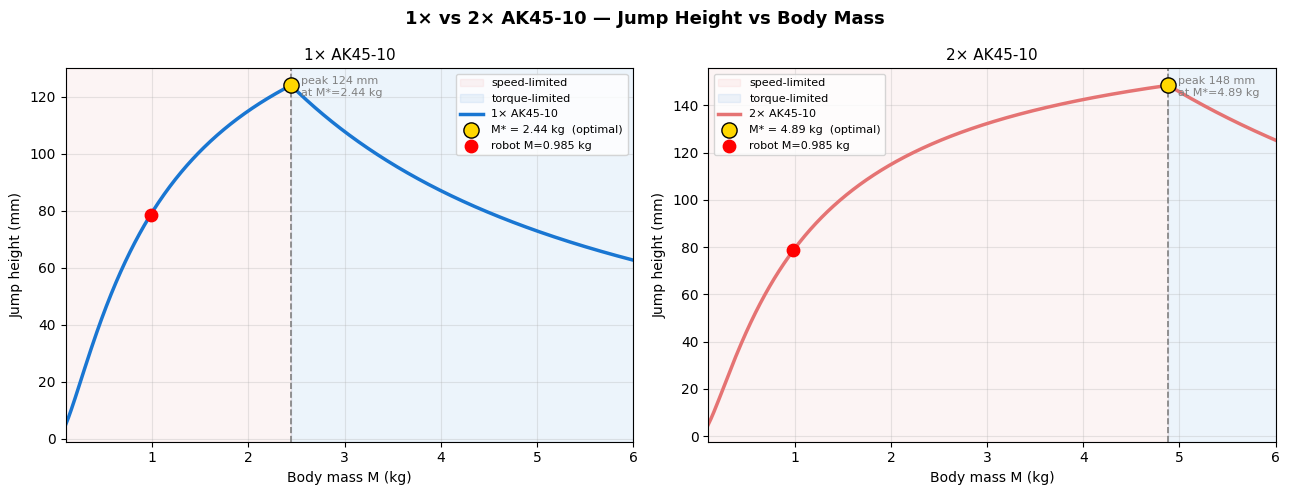

In [3]:
# ── 2× AK45-10: optimal body mass and stroke utilisation ─────────────────────
F_max_2x = 2 * F_max          # N    both legs
# v_max unchanged — each motor's no-load speed is independent
Mc_1x = crossover_mass(F_max,    v_max, d)
Mc_2x = crossover_mass(F_max_2x, v_max, d)

# Effective stroke the body actually uses before hitting v_max (speed-limited case)
# From work-energy: F_max_2x * d_eff = 0.5 * M * v_max^2
d_eff      = 0.5 * M0 * v_max**2 / F_max_2x   # m
stroke_used_pct = d_eff / d * 100

# Time to reach v_max under constant F_max_2x acceleration
a_body     = F_max_2x / M0      # m/s^2  (approximate: F stays near F_max while v << v_max)
t_to_vmax  = v_max / a_body     # s

# Stroke that would make robot body mass the optimal for 2x motors
d_opt_for_M0 = M0 * v_max**2 / (2 * F_max_2x)

# Jump height comparison
h_baseline = jump_height(M0, m0, F_max,    v_max, d) * 1000
h_2x       = jump_height(M0, m0, F_max_2x, v_max, d) * 1000
h_at_Mc_2x = jump_height(Mc_2x, m0, F_max_2x, v_max, d) * 1000

print("═══════════════════════════════════════════════════")
print("  2× AK45-10 JUMP ANALYSIS")
print("═══════════════════════════════════════════════════")
print(f"  F_max per leg       = {F_max:.1f} N")
print(f"  F_max both legs     = {F_max_2x:.1f} N")
print(f"  v_max (unchanged)   = {v_max:.3f} m/s")
print(f"  Stroke d            = {d*1000:.1f} mm")
print()
print(f"  M* (1 motor)        = {Mc_1x:.2f} kg")
print(f"  M* (2 motors)       = {Mc_2x:.2f} kg   ← optimal body mass")
print()
print("── Robot at M = {:.3f} kg (way below M*_2x) ──".format(M0))
print(f"  Effective stroke used  = {d_eff*1000:.1f} mm  of {d*1000:.1f} mm  ({stroke_used_pct:.0f}%)")
print(f"  Stroke wasted          = {(d-d_eff)*1000:.1f} mm  ({100-stroke_used_pct:.0f}%)")
print(f"  Time to reach v_max    ≈ {t_to_vmax*1000:.1f} ms  (then motor freewheels)")
print()
print(f"  h with 1× motor        = {h_baseline:.1f} mm")
print(f"  h with 2× motors       = {h_2x:.1f} mm   (no improvement — speed-limited in both cases)")
print()
print("── What stroke would match M=0.985 kg to 2× motors? ──")
print(f"  d_optimal              = {d_opt_for_M0*1000:.1f} mm  (vs current {d*1000:.1f} mm)")
print(f"  → current stroke is {d/d_opt_for_M0:.1f}× longer than needed for this body mass")
print()
print("── If body were at optimal M*_2x = {:.2f} kg ──".format(Mc_2x))
print(f"  h at M*_2x             = {h_at_Mc_2x:.1f} mm")

# ── Plot: h vs M for 1x and 2x motors side by side ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("1× vs 2× AK45-10 — Jump Height vs Body Mass", fontsize=13, fontweight="bold")

M_arr2 = np.linspace(0.1, 6.0, 600)

for ax, Fm, label, color in [
    (axes[0], F_max,    "1× AK45-10", "#1976D2"),
    (axes[1], F_max_2x, "2× AK45-10", "#E57373"),
]:
    Mc_  = crossover_mass(Fm, v_max, d)
    h_   = jump_height(M_arr2, m0, Fm, v_max, d) * 1000
    h_peak = jump_height(Mc_, m0, Fm, v_max, d) * 1000

    ax.axvspan(0.1, Mc_, alpha=0.08, color="#E57373", label="speed-limited")
    ax.axvspan(Mc_, 6.0, alpha=0.08, color="#1976D2", label="torque-limited")
    ax.plot(M_arr2, h_, color, lw=2.5, label=label)
    ax.axvline(Mc_, color="gray", lw=1.2, ls="--")
    ax.scatter([Mc_], [h_peak], color="gold", s=120, zorder=6,
               edgecolors="black", lw=1, label=f"M* = {Mc_:.2f} kg  (optimal)")
    ax.scatter([M0], [jump_height(M0, m0, Fm, v_max, d)*1000],
               color="red", s=80, zorder=5, label=f"robot M={M0} kg")
    ax.text(Mc_ + 0.1, h_peak * 0.97,
            f"peak {h_peak:.0f} mm\nat M*={Mc_:.2f} kg", fontsize=8, color="gray")
    ax.set_xlabel("Body mass M (kg)", fontsize=10)
    ax.set_ylabel("Jump height (mm)", fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.1, 6.0)

plt.tight_layout()
plt.show()

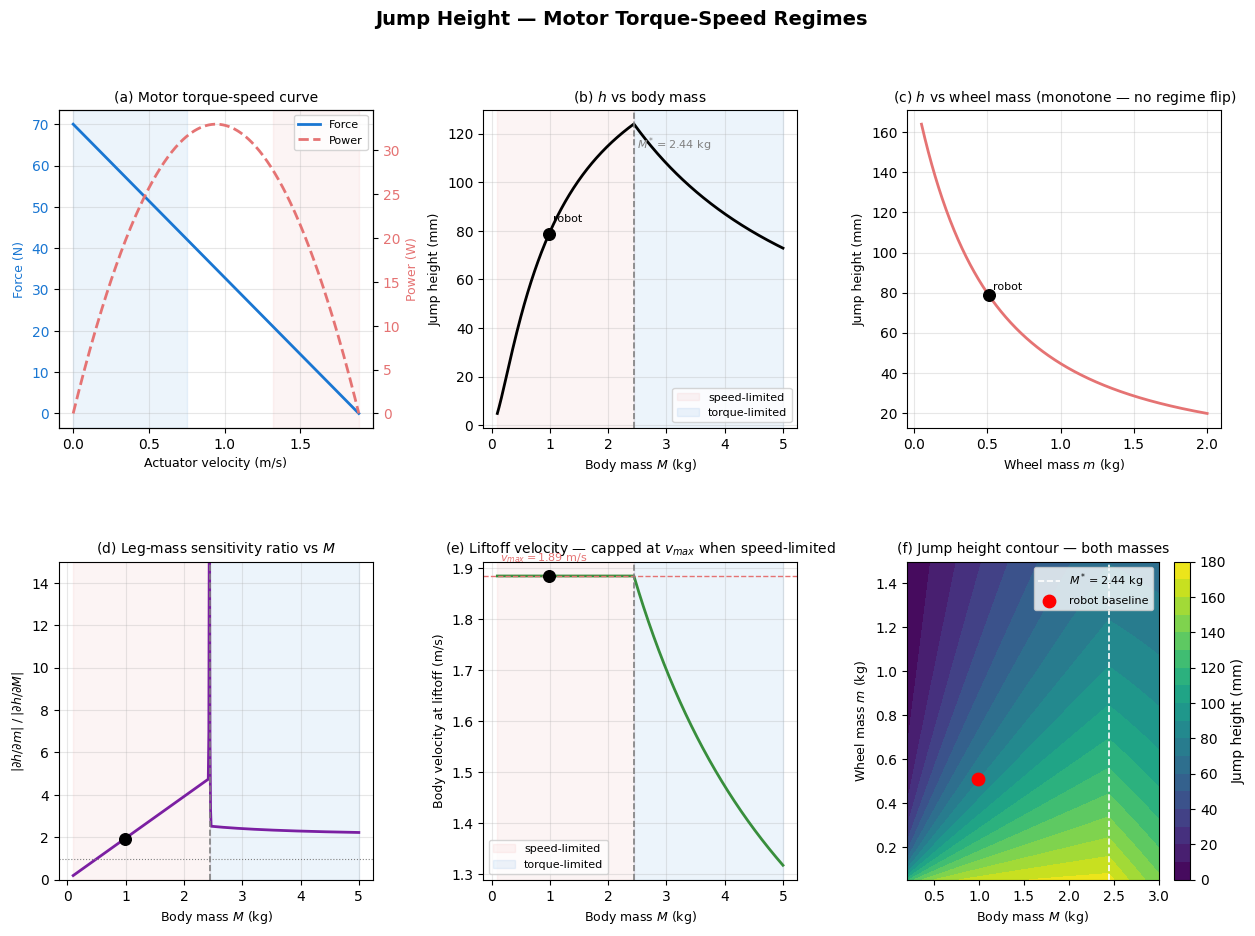

In [4]:
fig = plt.figure(figsize=(15, 10))
fig.suptitle("Jump Height — Motor Torque-Speed Regimes", fontsize=14, fontweight="bold")
gs = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

M_arr = np.linspace(0.1, 5.0, 500)
m_arr = np.linspace(0.05, 2.0, 500)
Mc    = crossover_mass(F_max, v_max, d)

# ── (a) Torque-speed curve ───────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
v_pts = np.linspace(0, v_max, 300)
F_pts = F_max * (1 - v_pts / v_max)
P_pts = F_pts * v_pts
ax0.plot(v_pts, F_pts, "#1976D2", lw=2, label="Force")
ax02 = ax0.twinx()
ax02.plot(v_pts, P_pts, "#E57373", lw=2, ls="--", label="Power")
ax02.set_ylabel("Power (W)", fontsize=9, color="#E57373")
ax02.tick_params(axis="y", labelcolor="#E57373")
# mark operating regimes
ax0.axvspan(0, v_max * 0.4, alpha=0.08, color="#1976D2", label="torque-lim region")
ax0.axvspan(v_max * 0.7, v_max, alpha=0.08, color="#E57373", label="speed-lim region")
ax0.set_xlabel("Actuator velocity (m/s)", fontsize=9)
ax0.set_ylabel("Force (N)", fontsize=9, color="#1976D2")
ax0.set_title("(a) Motor torque-speed curve", fontsize=10)
ax0.tick_params(axis="y", labelcolor="#1976D2")
lines1, labs1 = ax0.get_legend_handles_labels()
lines2, labs2 = ax02.get_legend_handles_labels()
ax0.legend(lines1[:1] + lines2, labs1[:1] + labs2, fontsize=8, loc="upper right")
ax0.grid(True, alpha=0.3)

# ── (b) h vs body mass M ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
h_M  = jump_height(M_arr, m0, F_max, v_max, d) * 1000
# shade regimes
ax1.axvspan(M_arr[0], Mc, alpha=0.08, color="#E57373", label="speed-limited")
ax1.axvspan(Mc, M_arr[-1], alpha=0.08, color="#1976D2", label="torque-limited")
ax1.plot(M_arr, h_M, "k", lw=2)
ax1.axvline(Mc, color="gray", lw=1.2, ls="--")
ax1.text(Mc + 0.05, max(h_M) * 0.92, f"$M^*={Mc:.2f}$ kg", fontsize=8, color="gray")
ax1.scatter([M0], [jump_height(M0, m0, F_max, v_max, d) * 1000],
            color="black", zorder=5, s=70)
ax1.text(M0 + 0.07, jump_height(M0, m0, F_max, v_max, d) * 1000 + 5,
         "robot", fontsize=8)
ax1.set_xlabel("Body mass $M$ (kg)", fontsize=9)
ax1.set_ylabel("Jump height (mm)", fontsize=9)
ax1.set_title("(b) $h$ vs body mass", fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── (c) h vs wheel mass m ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
h_m = jump_height(M0, m_arr, F_max, v_max, d) * 1000
ax2.plot(m_arr, h_m, "#E57373", lw=2)
ax2.scatter([m0], [jump_height(M0, m0, F_max, v_max, d) * 1000],
            color="black", zorder=5, s=70)
ax2.text(m0 + 0.03, jump_height(M0, m0, F_max, v_max, d) * 1000 + 3,
         "robot", fontsize=8)
ax2.set_xlabel("Wheel mass $m$ (kg)", fontsize=9)
ax2.set_ylabel("Jump height (mm)", fontsize=9)
ax2.set_title("(c) $h$ vs wheel mass (monotone — no regime flip)", fontsize=10)
ax2.grid(True, alpha=0.3)

# ── (d) sensitivity ratio across regimes ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
eps = 0.02
dh_dM = (jump_height(M_arr + eps, m0, F_max, v_max, d) -
          jump_height(M_arr - eps, m0, F_max, v_max, d)) / (2 * eps)
dh_dm = (jump_height(M_arr, m0 + eps, F_max, v_max, d) -
          jump_height(M_arr, m0 - eps, F_max, v_max, d)) / (2 * eps)
ratio = np.abs(dh_dm) / (np.abs(dh_dM) + 1e-12)
ratio_clipped = np.clip(ratio, 0, 20)
ax3.axvspan(M_arr[0], Mc, alpha=0.08, color="#E57373")
ax3.axvspan(Mc, M_arr[-1], alpha=0.08, color="#1976D2")
ax3.plot(M_arr, ratio_clipped, "#7B1FA2", lw=2)
ax3.axvline(Mc, color="gray", lw=1.2, ls="--")
ax3.axhline(1, color="gray", lw=0.8, ls=":")
ax3.scatter([M0], [np.interp(M0, M_arr, ratio_clipped)], color="black", s=70, zorder=5)
ax3.set_xlabel("Body mass $M$ (kg)", fontsize=9)
ax3.set_ylabel(r"$|\partial h/\partial m|\;/\;|\partial h/\partial M|$", fontsize=9)
ax3.set_title("(d) Leg-mass sensitivity ratio vs $M$", fontsize=10)
ax3.set_ylim(0, 15)
ax3.grid(True, alpha=0.3)

# ── (e) body liftoff velocity vs M ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
V_body = body_liftoff_velocity(M_arr, F_max, v_max, d)
ax4.axvspan(M_arr[0], Mc, alpha=0.08, color="#E57373", label="speed-limited")
ax4.axvspan(Mc, M_arr[-1], alpha=0.08, color="#1976D2", label="torque-limited")
ax4.plot(M_arr, V_body, "#388E3C", lw=2)
ax4.axhline(v_max, color="#E57373", lw=1, ls="--")
ax4.text(0.15, v_max + 0.03, f"$v_{{max}}={v_max:.2f}$ m/s", fontsize=8, color="#E57373")
ax4.axvline(Mc, color="gray", lw=1.2, ls="--")
ax4.scatter([M0], [float(body_liftoff_velocity(M0, F_max, v_max, d))],
            color="black", s=70, zorder=5)
ax4.set_xlabel("Body mass $M$ (kg)", fontsize=9)
ax4.set_ylabel("Body velocity at liftoff (m/s)", fontsize=9)
ax4.set_title("(e) Liftoff velocity — capped at $v_{max}$ when speed-limited", fontsize=10)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# ── (f) contour: h vs both masses ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
M_g = np.linspace(0.2, 3.0, 120)
m_g = np.linspace(0.05, 1.5, 120)
MM, mm_g = np.meshgrid(M_g, m_g)
HH = jump_height(MM, mm_g, F_max, v_max, d) * 1000
cf = ax5.contourf(M_g, m_g, HH, levels=20, cmap="viridis")
plt.colorbar(cf, ax=ax5, label="Jump height (mm)")
ax5.axvline(Mc, color="white", lw=1.2, ls="--", label=f"$M^*={Mc:.2f}$ kg")
ax5.scatter([M0], [m0], color="red", s=80, zorder=5, label="robot baseline")
ax5.set_xlabel("Body mass $M$ (kg)", fontsize=9)
ax5.set_ylabel("Wheel mass $m$ (kg)", fontsize=9)
ax5.set_title("(f) Jump height contour — both masses", fontsize=10)
ax5.legend(fontsize=8, loc="upper right")

plt.savefig("Jump_math_figures.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 — Interactive Explorer

Use the sliders to change masses and motor parameters and see jump height update live.

> **How to run interactively:**  
> Open a terminal in this folder and run:  
> ```
> jupyter lab
> ```  
> or  
> ```
> jupyter notebook
> ```  
> Then open `Jump_math.ipynb`, go to **Kernel → Restart & Run All**, and the sliders below will be live.  
> In VS Code: click **Run All** at the top of the notebook — widgets work natively with the Jupyter extension.

In [5]:
out = widgets.Output()

M_slider    = widgets.FloatSlider(value=M0,    min=0.1,  max=5.0,  step=0.05, description="M body (kg)",   style={"description_width":"120px"}, layout=widgets.Layout(width="500px"))
m_slider    = widgets.FloatSlider(value=m0,    min=0.05, max=2.0,  step=0.05, description="m wheel (kg)",  style={"description_width":"120px"}, layout=widgets.Layout(width="500px"))
Fmax_slider = widgets.FloatSlider(value=F_max, min=10,   max=200,  step=5.0,  description="F_max (N)",     style={"description_width":"120px"}, layout=widgets.Layout(width="500px"))
vmax_slider = widgets.FloatSlider(value=v_max, min=0.2,  max=5.0,  step=0.05, description="v_max (m/s)",   style={"description_width":"120px"}, layout=widgets.Layout(width="500px"))
d_slider    = widgets.FloatSlider(value=d,     min=0.01, max=0.20, step=0.005,description="stroke d (m)",  style={"description_width":"120px"}, layout=widgets.Layout(width="500px"))

readout = widgets.HTML(value="")

def update(change=None):
    M     = M_slider.value
    m     = m_slider.value
    Fmx   = Fmax_slider.value
    vmx   = vmax_slider.value
    dd    = d_slider.value
    Mc    = crossover_mass(Fmx, vmx, dd)
    h     = jump_height(M, m, Fmx, vmx, dd)
    h0_   = jump_height(M0, m0, F_max, v_max, d)
    regime = "speed-limited" if M <= Mc else "torque-limited"
    dh_dM_ = (jump_height(M + 0.05, m, Fmx, vmx, dd) - jump_height(M - 0.05, m, Fmx, vmx, dd)) / 0.10
    dh_dm_ = (jump_height(M, m + 0.05, Fmx, vmx, dd) - jump_height(M, m - 0.05, Fmx, vmx, dd)) / 0.10

    with out:
        out.clear_output(wait=True)

        M_arr_ = np.linspace(0.1, 5.0, 400)
        m_arr_ = np.linspace(0.05, 2.0, 400)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
        fig.suptitle(f"h = {h*1000:.1f} mm   |   regime: {regime}   |   M* = {Mc:.2f} kg",
                     fontsize=12, fontweight="bold")

        # Left: h vs M
        ax = axes[0]
        h_M_ = jump_height(M_arr_, m, Fmx, vmx, dd) * 1000
        ax.axvspan(0.1, Mc, alpha=0.08, color="#E57373")
        ax.axvspan(max(Mc, 0.1), 5.0, alpha=0.08, color="#1976D2")
        ax.plot(M_arr_, h_M_, "k", lw=2)
        ax.axvline(Mc, color="gray", lw=1, ls="--")
        ax.scatter([M], [h * 1000], color="red", s=100, zorder=5)
        ax.scatter([M0], [h0_ * 1000], color="blue", s=60, zorder=4, marker="x", label="baseline")
        ax.set_xlabel("Body mass M (kg)"); ax.set_ylabel("h (mm)")
        ax.set_title("h vs body mass"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

        # Middle: h vs m
        ax = axes[1]
        h_m_ = jump_height(M, m_arr_, Fmx, vmx, dd) * 1000
        ax.plot(m_arr_, h_m_, "#E57373", lw=2)
        ax.scatter([m], [h * 1000], color="red", s=100, zorder=5)
        ax.scatter([m0], [h0_ * 1000], color="blue", s=60, zorder=4, marker="x", label="baseline")
        ax.set_xlabel("Wheel mass m (kg)"); ax.set_ylabel("h (mm)")
        ax.set_title("h vs wheel mass"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

        # Right: sensitivity bars
        ax = axes[2]
        bars = ax.bar(["∂h/∂M\n(body)", "∂h/∂m\n(wheel)"],
                      [abs(dh_dM_) * 1000, abs(dh_dm_) * 1000],
                      color=["#388E3C", "#E57373"], width=0.5)
        for bar, val in zip(bars, [abs(dh_dM_)*1000, abs(dh_dm_)*1000]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")
        ax.set_ylabel("|dh/dm| (mm / kg)")
        ax.set_title(f"Sensitivity at current point\nRatio: {abs(dh_dm_)/(abs(dh_dM_)+1e-9):.1f}×")
        ax.grid(True, alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

    readout.value = (
        f"<b>h = {h*1000:.1f} mm</b> &nbsp;|&nbsp; "
        f"regime: <b>{regime}</b> &nbsp;|&nbsp; "
        f"M* = {Mc:.2f} kg &nbsp;|&nbsp; "
        f"∂h/∂M = {dh_dM_*1000:.0f} mm/kg &nbsp;|&nbsp; "
        f"∂h/∂m = {dh_dm_*1000:.0f} mm/kg &nbsp;|&nbsp; "
        f"ratio = {abs(dh_dm_)/(abs(dh_dM_)+1e-9):.1f}×"
    )

for sl in [M_slider, m_slider, Fmax_slider, vmax_slider, d_slider]:
    sl.observe(update, names="value")

ui = widgets.VBox([
    widgets.HTML("<h4>Parameters</h4>"),
    M_slider, m_slider,
    widgets.HTML("<hr><b>Motor</b>"),
    Fmax_slider, vmax_slider, d_slider,
    readout,
    out
])
display(ui)
update()

## 5 — Jump Animation

Visualises the two phases: extension (leg grounded, body rising) then free flight (whole system airborne).

In [6]:
plt.rcParams["animation.embed_limit"] = 30  # MB

def make_jump_animation(M, m, F_max, v_max, d, g=9.81):
    Mc  = crossover_mass(F_max, v_max, d)
    W   = F_max * d
    V   = v_max if M <= Mc else np.sqrt(2 * W / M)
    V_sys = M * V / (M + m)
    h   = V_sys**2 / (2 * g)

    L0  = 0.20   # m  resting leg length
    L1  = L0 + d # m  extended leg length

    # Phase 1: extension  (0 → t1)
    t1  = 0.12
    # Phase 2: free flight (t1 → t1 + t_flight)
    t_flight = 2 * V_sys / g
    t_total  = t1 + t_flight + 0.15

    n_frames = 80
    t_pts    = np.linspace(0, t_total, n_frames)

    fig, ax = plt.subplots(figsize=(5, 7))
    ax.set_xlim(-0.4, 0.4)
    ax.set_ylim(-0.05, h + L1 + 0.25)
    ax.set_aspect("equal")
    ax.axis("off")

    # ground
    ax.axhline(0, color="#555", lw=2)
    for xg in np.linspace(-0.35, 0.35, 12):
        ax.plot([xg, xg - 0.05], [0, -0.04], color="#555", lw=1)

    body_w, body_h = 0.18, 0.10
    body_rect = plt.Rectangle(
        (-body_w/2, L0), body_w, body_h,
        lw=1.5, edgecolor="#388E3C", facecolor="#C8E6C9", zorder=3)
    wheel_patch = plt.Circle((0, 0.04), 0.04, color="#E57373", zorder=3)
    leg_line,   = ax.plot([], [], "#1976D2", lw=3, zorder=2)
    info_text   = ax.text(0, h + L1 + 0.12, "", ha="center", fontsize=9)
    height_text = ax.text(0.22, 0.02, "", fontsize=8, color="gray")
    ax.add_patch(body_rect)
    ax.add_patch(wheel_patch)

    ax.axhline(L1 + h, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.text(0.22, L1 + h + 0.01, f"apex\n{h*1000:.0f} mm", fontsize=7, color="gray")

    def frame(i):
        t = t_pts[i]
        if t <= t1:
            frac      = t / t1
            leg_len   = L0 + frac * d
            body_base = leg_len
            wheel_y   = 0.04
            phase_str = "Extension"
        else:
            tf        = t - t1
            leg_len   = L1
            body_base = L1 + V_sys * tf - 0.5 * g * tf**2
            wheel_y   = body_base - leg_len + 0.04
            phase_str = "Free flight"

        body_rect.set_xy((-body_w/2, body_base))
        wheel_patch.center = (0, max(wheel_y, 0.04))
        leg_line.set_data([0, 0], [max(wheel_y, 0.04), body_base])
        info_text.set_text(f"{phase_str}   t={t:.2f}s")
        cg = (M * (body_base + body_h/2) + m * max(wheel_y, 0.04)) / (M + m)
        height_text.set_text(f"CG: {cg*1000:.0f} mm")
        return body_rect, wheel_patch, leg_line, info_text, height_text

    anim = FuncAnimation(fig, frame, frames=n_frames, interval=40, blit=True)
    plt.close(fig)
    return anim

anim = make_jump_animation(M0, m0, F_max, v_max, d)
HTML(anim.to_jshtml())

## 6 — Summary

| | Torque-limited ($M > M^*$) | Speed-limited ($M < M^*$) |
|---|---|---|
| Body mass effect | Hurts (partial self-compensation) | **Helps** — more momentum at fixed $v_\text{max}$ |
| Wheel mass effect | Always hurts — pure dead weight at liftoff | Always hurts |
| Sensitivity ratio | $2M/(M-m)$ ≈ **4.1×** | $M/m$ ≈ **1.9×** |
| Robot position | ← robot is here (M=0.985 kg > M*) | |

The fixed-energy model from Section 3 is valid for the robot's actual operating point ($M > M^*$).  
Wheel mass is the dominant lever because it contributes **zero momentum at liftoff** and **only adds inertia to be carried upward** — no compensating effect in either regime.